# CNN — Music Genre Group Classification

Classifying the three super-genre groups (**Acoustic**, **Rhythmic**, **Electric**) from GTZAN mel-spectrogram images using a Convolutional Neural Network.

**Input:** `images_remapped/` — 1000 PNG mel-spectrograms organised into 3 subfolders.  
Run `remap_images.py` first if you haven't already.

Sections:
1. Setup & imports
2. Data loading & augmentation
3. Explore the data
4. Build the CNN
5. Train the model
6. Evaluate — learning curves, confusion matrix, classification report

## 1. Setup & Imports

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.metrics import classification_report, confusion_matrix

print(f'TensorFlow version : {tf.__version__}')
print(f'GPU available      : {len(tf.config.list_physical_devices("GPU")) > 0}')

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

TensorFlow version : 2.21.0
GPU available      : False


## 2. Data Loading & Augmentation

In [4]:
# ── Config ────────────────────────────────────────────────────────────────────
DATA_DIR   = Path('data/images_remapped')   # output of remap_images.py
IMG_HEIGHT = 288
IMG_WIDTH  = 432
BATCH_SIZE = 32
EPOCHS     = 50          # EarlyStopping will cut this short if needed
NUM_CLASSES = 3
CLASS_NAMES = ['Acoustic', 'Electric', 'Rhythmic']  # alphabetical = Keras default order

# Verify folder structure
for cls in CLASS_NAMES:
    folder = DATA_DIR / cls
    n = len(list(folder.glob('*.png')))
    print(f'  {cls:<10} {n:>4} images  ->  {folder}')

  Acoustic    299 images  ->  data\images_remapped\Acoustic
  Electric    300 images  ->  data\images_remapped\Electric
  Rhythmic    400 images  ->  data\images_remapped\Rhythmic


In [5]:
# ── Train generator with augmentation ────────────────────────────────────────
# Augmentation adds variety to the 1000-image dataset without collecting new data.
# We keep transforms mild — spectrograms encode real frequency/time structure
# so we don't want to distort them too aggressively.
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    validation_split=0.2,
    horizontal_flip=True,       # time-mirror is musically reasonable
    width_shift_range=0.1,      # small time shifts
    height_shift_range=0.05,    # small frequency shifts
    zoom_range=0.05,
    brightness_range=[0.9, 1.1]
)

# Validation generator — rescale only, no augmentation
val_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    validation_split=0.2
)

train_gen = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=SEED
)

val_gen = val_datagen.flow_from_directory(
    DATA_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=SEED,
    shuffle=False   # keep order fixed for confusion matrix later
)

print(f'\nClass indices: {train_gen.class_indices}')
print(f'Train batches : {len(train_gen)}')
print(f'Val batches   : {len(val_gen)}')

# Class weights to handle Rhythmic (400) vs Acoustic/Electric (300) imbalance
from sklearn.utils.class_weight import compute_class_weight
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=train_gen.classes
)
class_weights = dict(enumerate(class_weights_arr))
print(f'\nClass weights: {class_weights}')

Found 800 images belonging to 3 classes.
Found 199 images belonging to 3 classes.

Class indices: {'Acoustic': 0, 'Electric': 1, 'Rhythmic': 2}
Train batches : 25
Val batches   : 7

Class weights: {0: np.float64(1.1111111111111112), 1: np.float64(1.1111111111111112), 2: np.float64(0.8333333333333334)}


## 3. Explore the Data

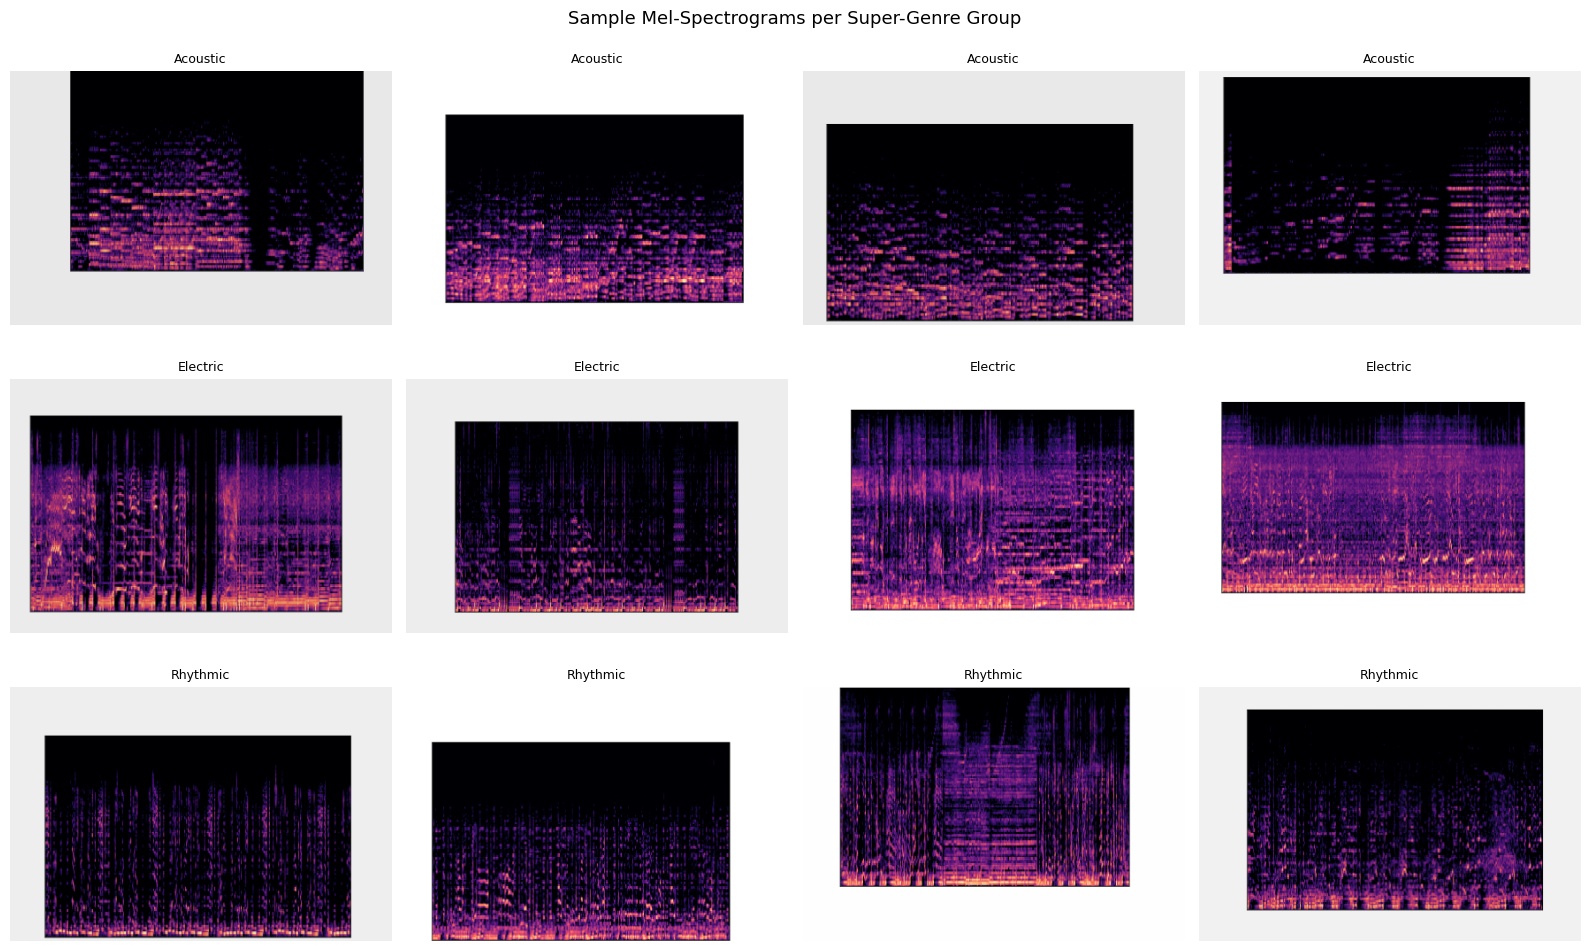

In [6]:
# Sample images from each class
idx_to_class = {v: k for k, v in train_gen.class_indices.items()}

images, labels = next(train_gen)

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
shown = {cls: 0 for cls in CLASS_NAMES}
plot_row = {'Acoustic': 0, 'Electric': 1, 'Rhythmic': 2}

for img, label_vec in zip(images, labels):
    cls = idx_to_class[np.argmax(label_vec)]
    col = shown[cls]
    if col < 4:
        axes[plot_row[cls], col].imshow(img)
        axes[plot_row[cls], col].set_title(cls, fontsize=9)
        axes[plot_row[cls], col].axis('off')
        shown[cls] += 1
    if all(v >= 4 for v in shown.values()):
        break

plt.suptitle('Sample Mel-Spectrograms per Super-Genre Group', fontsize=13)
plt.tight_layout()
plt.show()

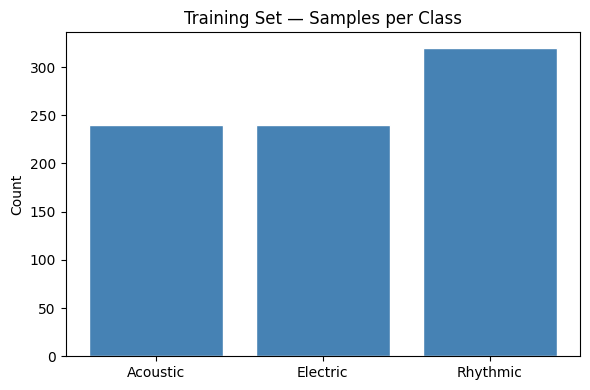

In [7]:
# Class distribution in train split
unique, counts = np.unique(train_gen.classes, return_counts=True)
plt.figure(figsize=(6, 4))
plt.bar([idx_to_class[i] for i in unique], counts, color='steelblue', edgecolor='white')
plt.title('Training Set — Samples per Class')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## 4. Build the CNN

Architecture overview:
- Three convolutional blocks (Conv → BatchNorm → ReLU → MaxPool → Dropout)
- Each block doubles the filter count: 32 → 64 → 128
- Global Average Pooling instead of Flatten — fewer parameters, less overfitting
- Dense head with L2 regularisation and Dropout
- Softmax output over 3 classes

In [8]:
def build_cnn(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3), num_classes=NUM_CLASSES):
    inputs = keras.Input(shape=input_shape)

    # ── Block 1 ───────────────────────────────────────────────────────────────
    x = layers.Conv2D(32, (3, 3), padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(32, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.25)(x)

    # ── Block 2 ───────────────────────────────────────────────────────────────
    x = layers.Conv2D(64, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(64, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.25)(x)

    # ── Block 3 ───────────────────────────────────────────────────────────────
    x = layers.Conv2D(128, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(128, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.25)(x)

    # ── Head ──────────────────────────────────────────────────────────────────
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name='genre_cnn')
    return model


model = build_cnn()
model.summary()

Model: "genre_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 288, 432, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 288, 432, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 288, 432, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 288, 432, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 288, 432, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 288, 432, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 288, 432, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 144, 216, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 144, 216, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 144, 216, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 144, 216, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 144, 216, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 144, 216, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 144, 216, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 144, 216, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 72, 108, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 72, 108, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 72, 108, 128)   │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 72, 108, 128)   │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 72, 108, 128)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 72, 108, 128)   │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 72, 108, 128)   │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 323,619 (1.23 MB)

 Trainable params: 322,211 (1.23 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [9]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('Model compiled.')

Model compiled.


## 5. Train the Model

In [10]:
callbacks = [
    # Stop training when val_loss stops improving
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    # Halve the learning rate when val_loss plateaus for 5 epochs
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),
    # Save the best model weights to disk
    ModelCheckpoint(
        filepath='best_cnn_weights.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

history = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.4789 - loss: 1.1075 
Epoch 1: val_accuracy improved from None to 0.22111, saving model to best_cnn_weights.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 298s 12s/step - accuracy: 0.5325 - loss: 1.0024 - val_accuracy: 0.2211 - val_loss: 1.1158 - learning_rate: 0.0010
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.6323 - loss: 0.8788 
Epoch 2: val_accuracy improved from 0.22111 to 0.30151, saving model to best_cnn_weights.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 270s 11s/step - accuracy: 0.6175 - loss: 0.8773 - val_accuracy: 0.3015 - val_loss: 1.1543 - learning_rate: 0.0010
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.6458 - loss: 0.8155 
Epoch 3: val_accuracy did not improve from 0.30151
25/25 ━━━━━━━━━━━━━━━━━━━━ 266s 11s/step - accuracy: 0.6525 - loss: 0.7817 - val_accuracy: 0.3015 - val_loss: 1.3628 - learning_rate: 0.0010
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.6319 - loss: 0.8180


## 6. Evaluation

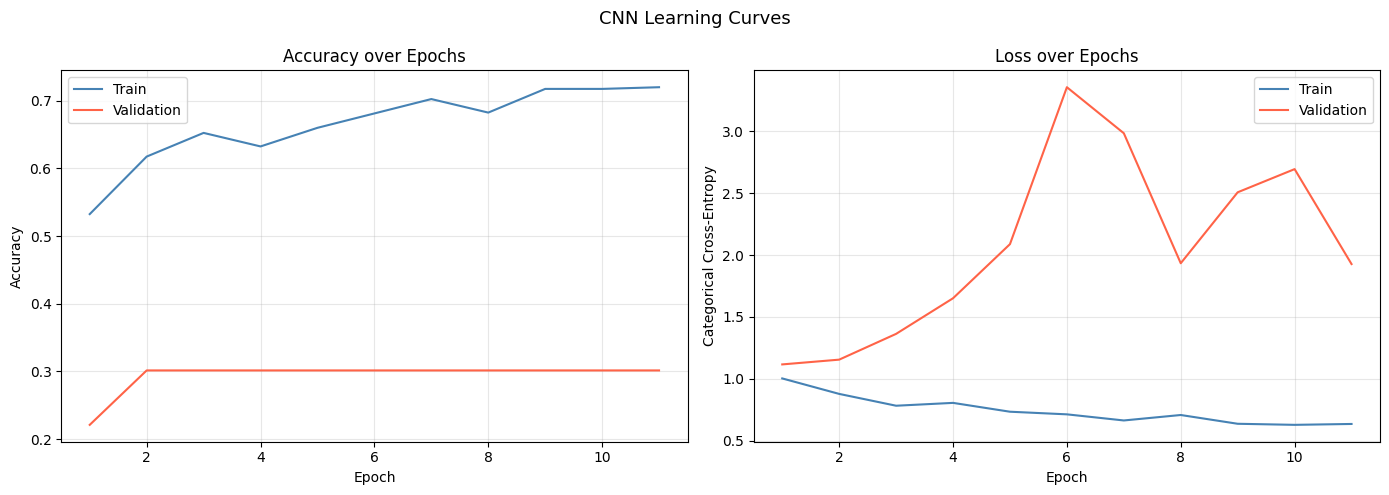

In [11]:
# ── Learning curves ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_ran = range(1, len(history.history['accuracy']) + 1)

# Accuracy
axes[0].plot(epochs_ran, history.history['accuracy'],     label='Train',      color='steelblue')
axes[0].plot(epochs_ran, history.history['val_accuracy'], label='Validation', color='tomato')
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(epochs_ran, history.history['loss'],     label='Train',      color='steelblue')
axes[1].plot(epochs_ran, history.history['val_loss'], label='Validation', color='tomato')
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Categorical Cross-Entropy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('CNN Learning Curves', fontsize=13)
plt.tight_layout()
plt.show()

In [12]:
# ── Final metrics on validation set ──────────────────────────────────────────
from sklearn.metrics import accuracy_score, f1_score

# Load best weights (already restored by EarlyStopping, but explicit is safer)
model.load_weights('best_cnn_weights.keras')

val_gen.reset()
y_pred_proba = model.predict(val_gen, verbose=0)
y_pred       = np.argmax(y_pred_proba, axis=1)
y_true       = val_gen.classes

acc   = accuracy_score(y_true, y_pred)
f1_w  = f1_score(y_true, y_pred, average='weighted')
f1_m  = f1_score(y_true, y_pred, average='macro')

print('=== CNN (best checkpoint) ===')
print(f'Accuracy   : {acc:.4f}')
print(f'Weighted F1: {f1_w:.4f}')
print(f'Macro F1   : {f1_m:.4f}')
print()
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

=== CNN (best checkpoint) ===
Accuracy   : 0.3015
Weighted F1: 0.1397
Macro F1   : 0.1544

              precision    recall  f1-score   support

    Acoustic       0.00      0.00      0.00        59
    Electric       0.30      1.00      0.46        60
    Rhythmic       0.00      0.00      0.00        80

    accuracy                           0.30       199
   macro avg       0.10      0.33      0.15       199
weighted avg       0.09      0.30      0.14       199



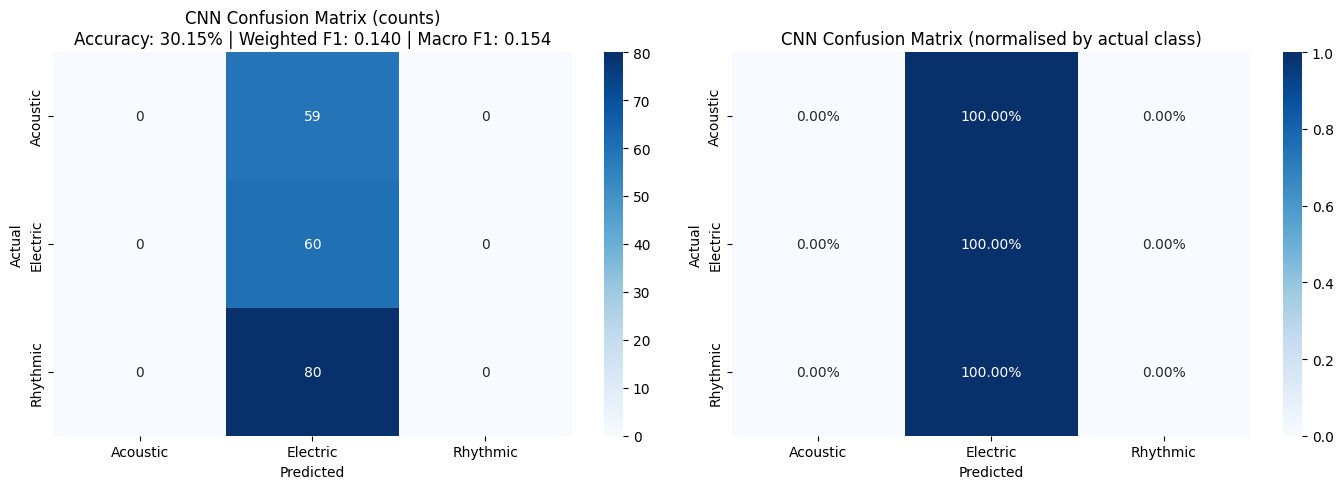

In [13]:
# ── Confusion matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title(
    f'CNN Confusion Matrix (counts)\n'
    f'Accuracy: {acc:.2%} | Weighted F1: {f1_w:.3f} | Macro F1: {f1_m:.3f}'
)
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Normalised
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
axes[1].set_title('CNN Confusion Matrix (normalised by actual class)')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

In [ ]:
# ── Misclassified samples ─────────────────────────────────────────────────────
# Visualise images the model got wrong — useful for the report
val_gen.reset()
all_images, all_labels = [], []
for _ in range(len(val_gen)):
    imgs, lbls = next(val_gen)
    all_images.append(imgs)
    all_labels.append(lbls)

all_images = np.concatenate(all_images, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

wrong_idx = np.where(y_pred != y_true)[0]
print(f'Misclassified: {len(wrong_idx)} / {len(y_true)}')

n_show = min(8, len(wrong_idx))
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, idx in enumerate(wrong_idx[:n_show]):
    axes[i].imshow(all_images[idx])
    axes[i].set_title(
        f'True: {CLASS_NAMES[y_true[idx]]}\nPred: {CLASS_NAMES[y_pred[idx]]}',
        fontsize=9, color='red'
    )
    axes[i].axis('off')

plt.suptitle('Sample Misclassified Images', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# ── Final summary table ───────────────────────────────────────────────────────
# Fill in RF and XGBoost results from those notebooks
summary = pd.DataFrame({
    'Model'      : [
        'Naive Baseline',
        'KNN',
        'Random Forest (tuned)',
        'XGBoost (tuned)',
        'CNN'
    ],
    'Accuracy'   : [0.552, 0.7267, 0.82,0.86, round(acc,  4)],
    'Weighted F1': [0.53, 0.73, 0.81, 0.86, round(f1_w, 4)],
    'Macro F1'   : [0.55, 0.73, 0.84, 0.86, round(f1_m, 4)]
})
print(summary.to_string(index=False))

                Model  Accuracy  Weighted F1  Macro F1
       Naive Baseline    0.5520       0.5300    0.5500
                  KNN    0.7267       0.7300    0.7300
Random Forest (tuned)    0.8200       0.8100    0.8400
      XGBoost (tuned)    0.8600       0.8600    0.8600
                  CNN    0.3015       0.1397    0.1544


: 